# 02 - Tarea guiada: métricas y evaluación por archivo

En esta tarea **no se usa `course_utils.metrics`**. Primero defines tus propias funciones de métricas y luego las usas para construir una evaluación completa por archivo y por modelo.

Puedes usar `course_utils.data`, `course_utils.palette` y `course_utils.plotting`, pero las métricas son tu responsabilidad.

In [6]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from course_utils.data import (
    SAMPLE_FILES,
    SAMPLE_FILES_piura,
    LEAD_MINUTES,
    get_paths,
    load_sample,
    split_sequence,
    load_prediction,
    make_persistence_prediction,
)
from course_utils.palette import apply_course_style, RAIN_LEVELS
from course_utils.plotting import plot_event_grid, plot_target_prediction_panel, plot_rmse_bias, plot_csi_by_threshold

apply_course_style()
paths = get_paths(PROJECT_ROOT)

THRESHOLDS = [0.5, 2.0, 5.0, 10.0]
THRESHOLD_LABELS = {
    0.5: "lluvia ligera",
    2.0: "lluvia moderada",
    5.0: "lluvia fuerte",
    10.0: "lluvia intensa",
}

print(f"Proyecto: {paths.root}")
print(f"Muestras: {paths.sample_dir}")

ImportError: cannot import name 'SAMPLE_FILES_piura' from 'course_utils.data' (/home/henryjuarez/code_andre_sophy/nowcasting_course_lab/course_utils/data.py)

## 1. Cargar un caso

Elige una muestra. Si existen predicciones de CasCast/EarthFormer se cargarán; si no, se usará persistencia.

In [5]:
sample_name = SAMPLE_FILES_piura[0]  # TODO: prueba otros casos
sequence = load_sample(sample_name, paths)
inputs, target = split_sequence(sequence)
prediction, prediction_source = load_prediction(sample_name, inputs, paths)

print(sample_name)
print("Fuente:", prediction_source)
print("inputs:", inputs.shape, "target:", target.shape, "prediction:", prediction.shape)
print("Niveles de color mm/h:", RAIN_LEVELS)

NameError: name 'SAMPLE_FILES_piura' is not defined

## 2. Visualización inicial

Responde: ¿hacia dónde se mueve la tormenta?, ¿la predicción conserva los máximos?, ¿hay desplazamiento espacial?

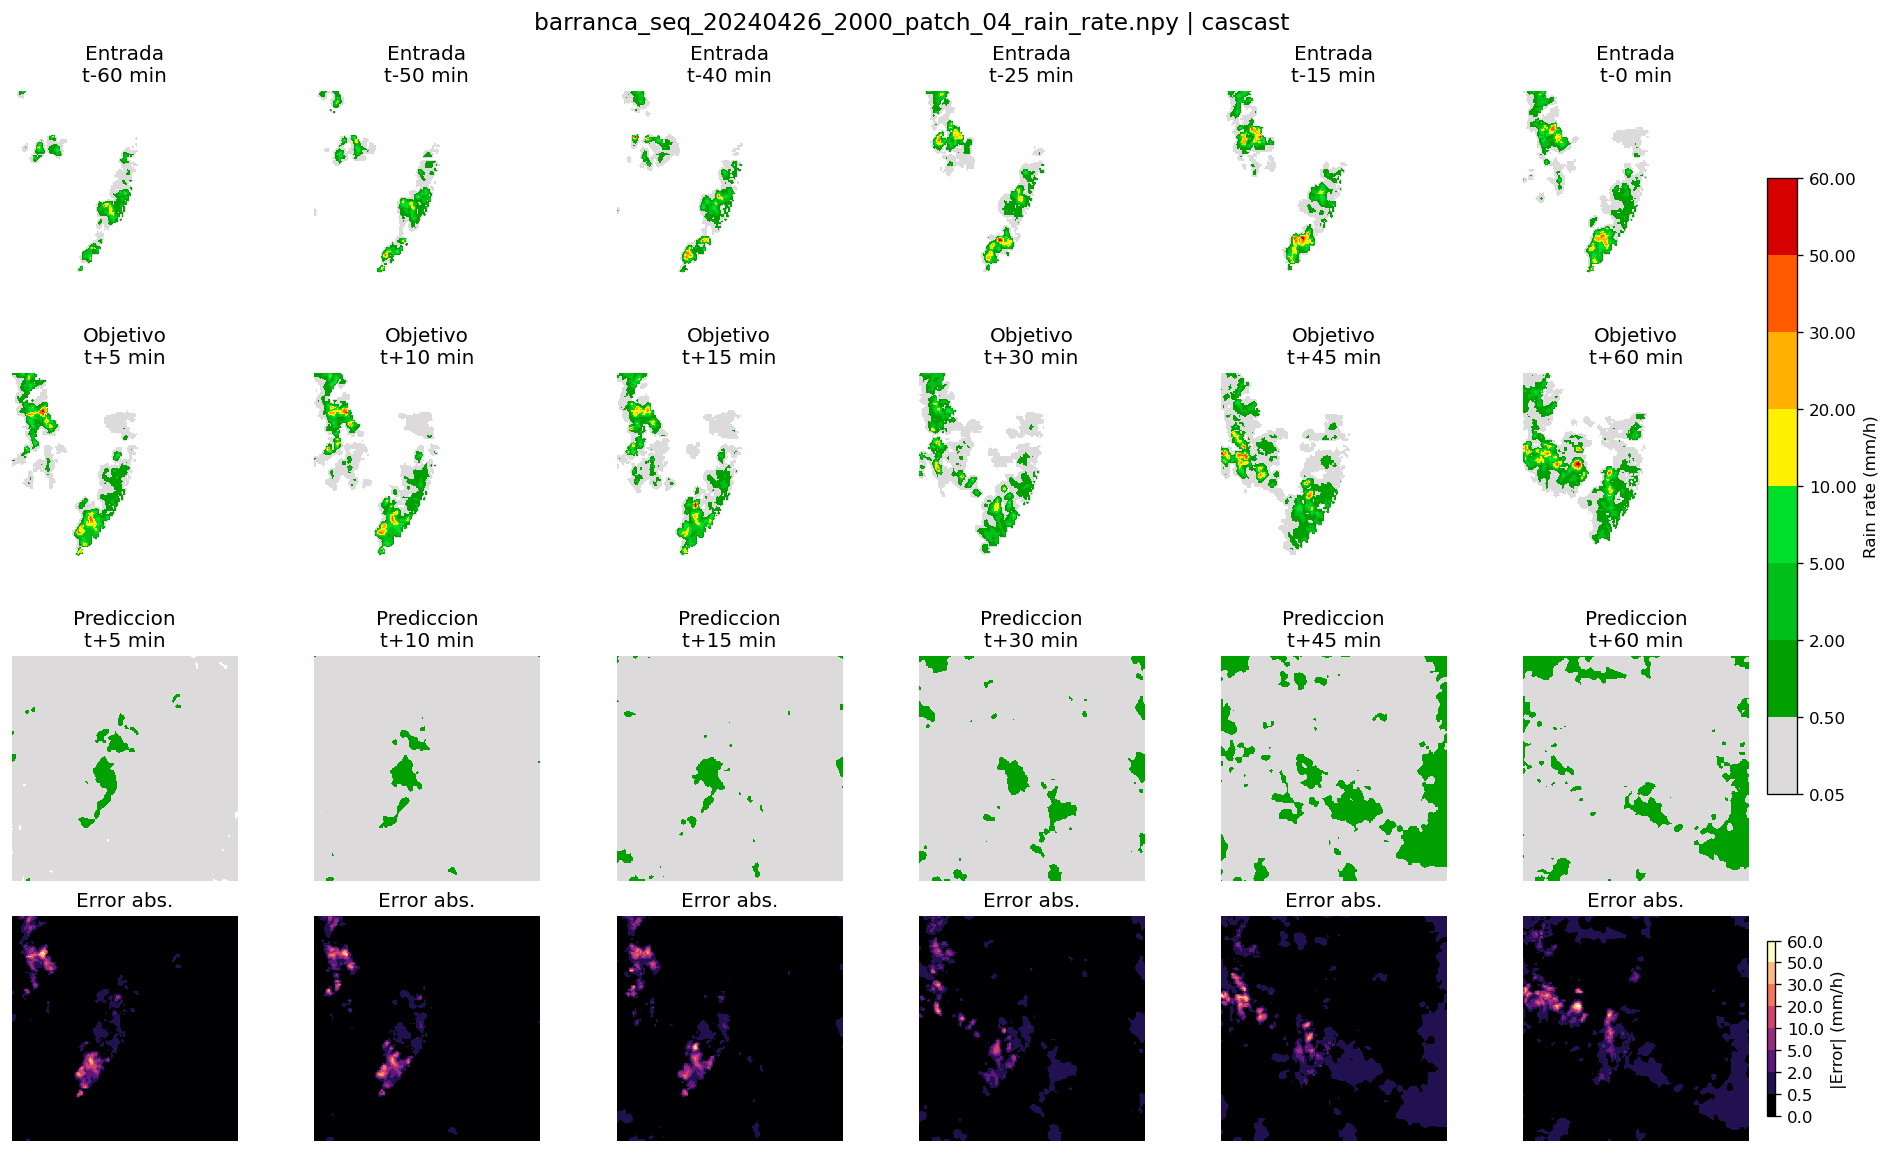

In [4]:
fig = plot_event_grid(inputs, target, prediction, sample_name, prediction_source)
plt.show()

## 3. Definir métricas continuas

Fórmulas:

$$
\mathrm{MAE}_k = \frac{1}{HW}\sum_{i,j}|\hat{Y}_{k,i,j} - Y_{k,i,j}|
$$

$$
\mathrm{RMSE}_k = \sqrt{\frac{1}{HW}\sum_{i,j}(\hat{Y}_{k,i,j} - Y_{k,i,j})^2}
$$

$$
\mathrm{Bias}_k = \frac{1}{HW}\sum_{i,j}(\hat{Y}_{k,i,j} - Y_{k,i,j})
$$

In [ ]:
def safe_pearson_student(x, y):
    x_flat = x.ravel()
    y_flat = y.ravel()
    mask = np.isfinite(x_flat) & np.isfinite(y_flat)
    x_flat, y_flat = x_flat[mask], y_flat[mask]
    if x_flat.std() == 0 or y_flat.std() == 0:
        return np.nan
    return np.corrcoef(x_flat, y_flat)[0, 1]


def compute_continuous_metrics(pred, target):
    """Devuelve DataFrame con lead_min, MAE, RMSE, Bias, Pearson_r."""
    rows = []
    for i, lead in enumerate(LEAD_MINUTES):
        error = pred[i] - target[i]
        mae = np.mean(np.abs(error))
        rmse = np.sqrt(np.mean(error ** 2))
        bias = np.mean(error)
        pearson_r = safe_pearson_student(pred[i], target[i])
        rows.append({"lead_min": int(lead), "MAE": mae, "RMSE": rmse, "Bias": bias, "Pearson_r": pearson_r})
    return pd.DataFrame(rows)

In [ ]:
continuous_student = compute_continuous_metrics(prediction, target)
continuous_student

In [ ]:
fig = plot_rmse_bias(continuous_student)
plt.show()

## 4. Definir métricas binarias

Para umbral $\tau$:

$$
CSI = \frac{TP}{TP + FP + FN}
$$

$$
POD = \frac{TP}{TP + FN}, \qquad FAR = \frac{FP}{TP + FP}
$$

$$
Precision = \frac{TP}{TP + FP}, \qquad Recall = \frac{TP}{TP + FN}
$$

$$
F1 = \frac{2TP}{2TP + FP + FN}
$$

Si el denominador es cero, devuelve `np.nan`.

In [ ]:
def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator


def compute_binary_metrics(pred, target, threshold):
    """Calcula TP, FP, FN, TN, CSI, POD, FAR, Precision, Recall y F1."""
    pred_event = pred >= threshold
    target_event = target >= threshold
    TP = int(np.logical_and(pred_event, target_event).sum())
    FP = int(np.logical_and(pred_event, ~target_event).sum())
    FN = int(np.logical_and(~pred_event, target_event).sum())
    TN = int(np.logical_and(~pred_event, ~target_event).sum())
    CSI       = safe_divide(TP, TP + FP + FN)
    POD       = safe_divide(TP, TP + FN)
    FAR       = safe_divide(FP, TP + FP)
    Precision = safe_divide(TP, TP + FP)
    Recall    = safe_divide(TP, TP + FN)
    F1        = safe_divide(2 * TP, 2 * TP + FP + FN)
    return {"TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "CSI": CSI, "POD": POD, "FAR": FAR,
            "Precision": Precision, "Recall": Recall, "F1": F1}


def event_metrics_by_threshold_and_lead_student(pred, target, thresholds=THRESHOLDS):
    """Aplica compute_binary_metrics para cada lead time y umbral."""
    rows = []
    for threshold in thresholds:
        for i, lead in enumerate(LEAD_MINUTES):
            metrics = compute_binary_metrics(pred[i], target[i], threshold)
            rows.append({"threshold_mm_h": threshold, "lead_min": int(lead), **metrics})
    return pd.DataFrame(rows)

In [ ]:
event_student = event_metrics_by_threshold_and_lead_student(prediction, target, THRESHOLDS)
event_student.head()

In [ ]:
fig = plot_csi_by_threshold(event_student)
plt.show()

## 5. Pipeline de evaluación por archivo

Ahora integra tus funciones: para cada archivo y cada predicción disponible, calcula promedios por caso.

Esta es la parte más importante de la tarea porque convierte funciones sueltas en un pequeño pipeline reproducible.

In [ ]:
def available_predictions_for_case_student(name):
    """Devuelve target y predicciones disponibles para un archivo."""
    seq = load_sample(name, paths)
    x, y = split_sequence(seq)
    predictions = {"persistence": make_persistence_prediction(x)}

    for label, folder in [("earthformer", paths.earthformer_dir), ("cascast", paths.cascast_dir), ("model", paths.model_dir)]:
        pred_path = folder / name
        if pred_path.exists():
            predictions[label] = np.nan_to_num(np.load(pred_path).astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    return y, predictions


def evaluate_all_files_student(sample_files=SAMPLE_FILES):
    """Usa las métricas definidas para construir una tabla por archivo y modelo."""
    rows = []
    for name in sample_files:
        target_case, predictions = available_predictions_for_case_student(name)
        for model_name, pred_case in predictions.items():
            continuous_df = compute_continuous_metrics(pred_case, target_case)
            event_df = event_metrics_by_threshold_and_lead_student(pred_case, target_case, THRESHOLDS)
            csi_05  = event_df[event_df["threshold_mm_h"] == 0.5]["CSI"].mean()
            csi_5   = event_df[event_df["threshold_mm_h"] == 5.0]["CSI"].mean()
            csi_10  = event_df[event_df["threshold_mm_h"] == 10.0]["CSI"].mean()
            rows.append({
                "file":         name,
                "model":        model_name,
                "RMSE_mean":    continuous_df["RMSE"].mean(),
                "MAE_mean":     continuous_df["MAE"].mean(),
                "Bias_mean":    continuous_df["Bias"].mean(),
                "Pearson_mean": continuous_df["Pearson_r"].mean(),
                "CSI_0.5_mean": csi_05,
                "CSI_5_mean":   csi_5,
                "CSI_10_mean":  csi_10,
            })
    return pd.DataFrame(rows)

In [ ]:
all_file_metrics = evaluate_all_files_student(SAMPLE_FILES_piura)
all_file_metrics

In [ ]:
overall_metrics = (
    all_file_metrics
    .groupby("model", as_index=False)
    [["RMSE_mean", "MAE_mean", "Bias_mean", "Pearson_mean", "CSI_0.5_mean", "CSI_5_mean", "CSI_10_mean"]]
    .mean(numeric_only=True)
    .sort_values("RMSE_mean")
)
overall_metrics

In [ ]:
if len(all_file_metrics["model"].unique()) > 1:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    for model_name, group in all_file_metrics.groupby("model"):
        ax.scatter(group["RMSE_mean"], group["CSI_10_mean"], label=model_name, s=60)
    ax.set_xlabel("RMSE promedio (mm/h)")
    ax.set_ylabel("CSI promedio a 10 mm/h")
    ax.set_title("Error promedio vs lluvia intensa")
    ax.legend()
    plt.show()

## 6. Preguntas de análisis

Responde:

1. ¿Por qué CSI suele ser más alto para 0.5 mm/h que para 10 mm/h?
2. ¿Qué modelo o línea base tiene menor RMSE promedio?
3. ¿Qué modelo o línea base tiene mejor CSI a 10 mm/h?
4. ¿Hay casos donde RMSE mejora pero CSI intenso empeora?
5. ¿Qué caso parece más difícil y por qué?

## 7. Reflexión final

Escribe entre 300 y 500 palabras:

> ¿Por qué un modelo puede tener bajo RMSE pero baja utilidad para nowcasting de lluvia intensa?

Tu respuesta debe mencionar suavizado, núcleos intensos, desplazamiento espacial y por qué métricas como CSI ayudan a evaluar eventos relevantes.